import pandas as pd

import seaborn as sns

import numpy as np

import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel(r"C:\Users\nihal\PycharmProjects\project_data_clean.xlsx")


In [6]:
df.head()

,Sl.no,Age,Gender,Literacy Status,Highest Qualification,Field of Study,Experience Sector,Job-Related Skills,Household Size,Employed Members,Exams Attempted,Willing to Relocate,Digital Literacy,Disability Status,Caste/Category,Marital Status,Access to Coaching/Training,Eligiblity
0,1,28,Male,Literate,Graduate,History,1,Academic Writing,8,5,NaN,Yes,Intermediate,NaN,OBC,Single,Local Coaching,yes
1,2,44,Male,Literate,Below 10th,NaN,0,NaN,4,4,NaN,Yes,Beginner,NaN,ST,Married,NaN,no
2,3,45,Male,Literate,Postgraduate,Sociology,1,Social Research,5,2,NaN,No,Advanced,NaN,ST,Single,Online Courses,yes
3,4,37,Female,Literate,10th,NaN,0,NaN,7,7,NaN,Yes,Beginner,NaN,GENERAL,Single,1 Program,yes
4,5,22,Female,Literate,Graduate,History,0,Academic Writing,4,3,NaN,No,Intermediate,Visual,GENERAL,Married,NaN,yes


In [18]:
df.shape
#the dimensions of your DataFrame

(107, 17)

In [7]:
df.info

<bound method DataFrame.info of      Sl.no  Age  Gender Literacy Status Highest Qualification  \
0        1   28    Male        Literate              Graduate   
1        2   44    Male        Literate            Below 10th   
2        3   45    Male        Literate          Postgraduate   
3        4   37  Female        Literate                  10th   
4        5   22  Female        Literate              Graduate   
..     ...  ...     ...             ...                   ...   
102    103   25    Male        Literate              Graduate   
103    104   19  Female        Literate                  12th   
104    105   26  Female        Literate          Postgraduate   
105    106   24  Female        Literate          Postgraduate   
106    107   30  Female        Literate          Postgraduate   

                        Field of Study  Experience Sector  \
0                              History                  1   
1                                  NaN                  0   
2   

In [19]:
df.describe()
#quick statistical summary of the numeric columns in your DataFrame

,Age,Experience Sector,Household Size,Employed Members
count,107.000000,107.000000,107.000000,107.000000
mean,29.560748,0.364486,5.112150,3.411215
std,8.780529,0.483551,1.996823,1.942345
min,18.000000,0.000000,2.000000,1.000000
25%,22.000000,0.000000,3.000000,2.000000
50%,28.000000,0.000000,5.000000,3.000000
75%,37.000000,1.000000,7.000000,5.000000
max,50.000000,1.000000,8.000000,8.000000


In [ ]:
#CLEANING

In [8]:
# Drop 'Sl.no' column
df.drop(columns=['Sl.no'], inplace=True)


In [12]:
# Strip whitespace and convert text to consistent casing (title or lowercase)
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

In [30]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [14]:
# Convert 'None' and empty strings to NaN
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'None': pd.NA, 'none': pd.NA, '': pd.NA})
    if col != "Field of Study" and col != "Job-Related Skills":
        df[col] = df[col].str.lower()


In [17]:
    # Standardize text casing for categorical values
    if col != "Field of Study" and col != "Job-Related Skills":
        df[col] = df[col].str.lower()



In [20]:
df.isnull().sum()
#find missing (null/NaN) values in your DataFrame.

Age                            0
Gender                         0
Literacy Status                0
Highest Qualification          0
Field of Study                 0
Experience Sector              0
Job-Related Skills             0
Household Size                 0
Employed Members               0
Exams Attempted                0
Willing to Relocate            0
Digital Literacy               0
Disability Status              0
Caste/Category                 0
Marital Status                 0
Access to Coaching/Training    0
Eligiblity                     0
dtype: int64

In [21]:
# Drop rows with 6 or more missing values
df = df.dropna(thresh=df.shape[1] - 6)

In [22]:

if 'access to coaching/training' in df.columns:
    df['access to coaching/training'] = df['access to coaching/training'].replace({'n0': 'no', 'na': 'no', 'none': 'no', 'nil': 'no'})

if 'disability status' in df.columns:
    df['disability status'] = df['disability status'].replace({'none': 'no', 'n/a': 'no', 'na': 'no'})

if 'exams attempted' in df.columns:
    df['exams attempted'] = df['exams attempted'].replace({'none': 'no', 'na': 'no', 'n0': 'no', 'nil': 'no'})

In [23]:
 # Drop duplicate rows
df.drop_duplicates(inplace=True)

In [27]:
# Convert some cleaned binary columns to 'category' type
cat_cols = ['exams attempted', 'disability status', 'access to coaching/training']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')


In [29]:
df.to_excel("cleaned_data.xlsx", index=False)


In [ ]:
#VISUALIZATION

In [38]:
print(df.columns)



Index(['age', 'gender', 'literacy_status', 'highest_qualification',
       'field_of_study', 'experience_sector', 'job-related_skills',
       'household_size', 'employed_members', 'exams_attempted',
       'willing_to_relocate', 'digital_literacy', 'disability_status',
       'caste/category', 'marital_status', 'access_to_coaching/training',
       'eligiblity'],
      dtype='object')


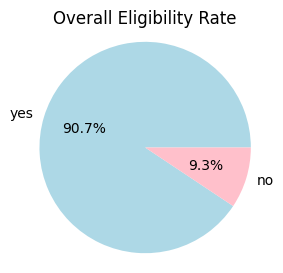

In [48]:
# Overall eligibility rate
plt.figure(figsize=(3, 3))
labels = df['eligiblity'].value_counts().index
sizes = df['eligiblity'].value_counts().values

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'pink'])
plt.title('Overall Eligibility Rate')
plt.axis('equal')
plt.show()


In [ ]:
#Sociodemographic Attributes


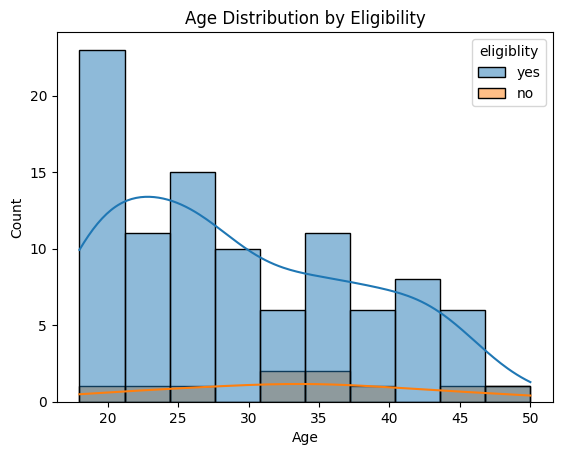

In [69]:
sns.histplot(data=df, x='age', hue='eligiblity', kde=True, bins=10)
plt.title('Age Distribution by Eligibility')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

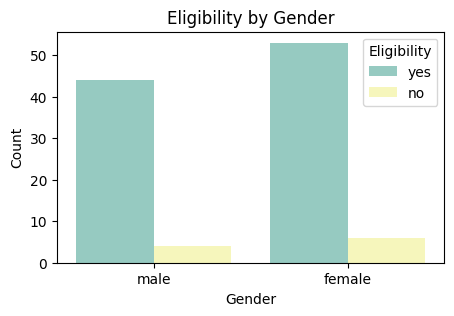

In [52]:
#Gender-wise Eligibility
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='gender', hue='eligiblity', palette='Set3')
plt.title('Eligibility by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()

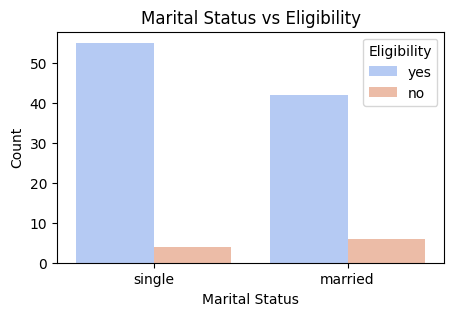

In [92]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='marital_status', hue='eligiblity', palette='coolwarm')
plt.title('Marital Status vs Eligibility')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()


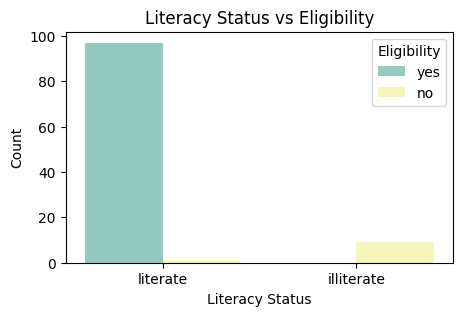

In [56]:
# Literacy Status vs Eligibility
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='literacy_status', hue='eligiblity', palette='Set3')
plt.title('Literacy Status vs Eligibility')
plt.xlabel('Literacy Status')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()

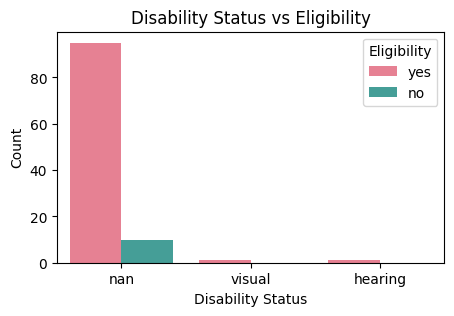

In [90]:
# Disability Status and Eligibility
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='disability_status', hue='eligiblity', palette='husl')
plt.title('Disability Status vs Eligibility')
plt.xlabel('Disability Status')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()

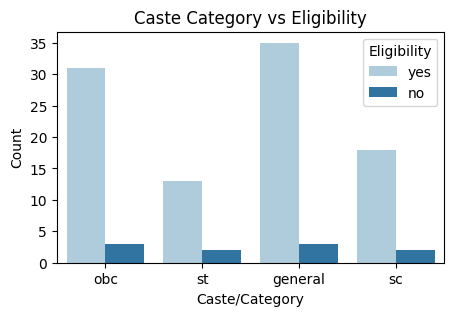

In [91]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='caste/category', hue='eligiblity', palette='Paired')
plt.title('Caste Category vs Eligibility')
plt.xlabel('Caste/Category')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()


In [ ]:
#Socioeconomic Attributes

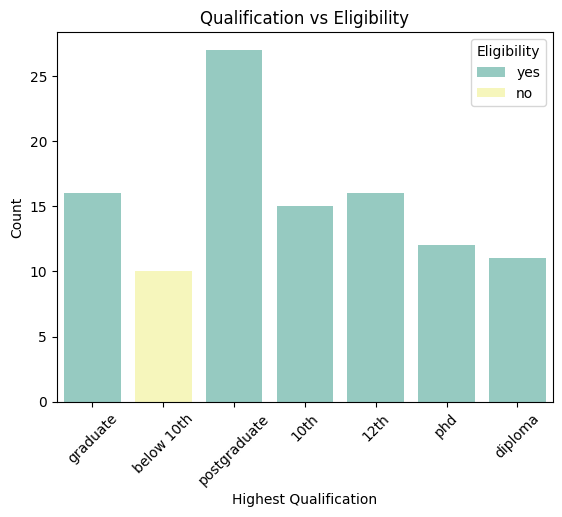

In [60]:
#Highest Qualification vs Eligibility

sns.countplot(data=df, x='highest_qualification', hue='eligiblity', palette='Set3')
plt.title('Qualification vs Eligibility')
plt.xticks(rotation=45)
plt.xlabel('Highest Qualification')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()

In [88]:
most_common_qualification = df['highest_qualification'].value_counts().idxmax()
count = df['highest_qualification'].value_counts().max()

print("Most common qualification:", most_common_qualification)
print("Count:", count)

Most common qualification: postgraduate
Count: 27


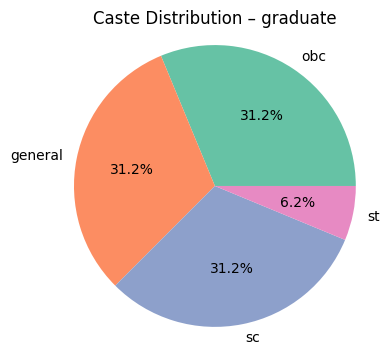

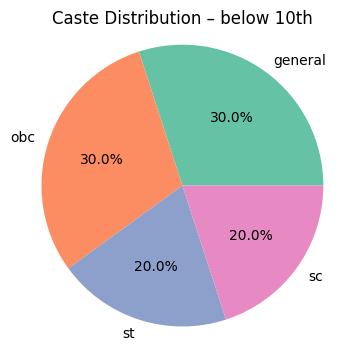

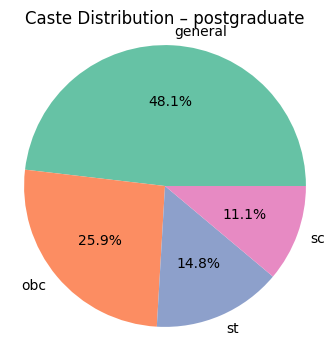

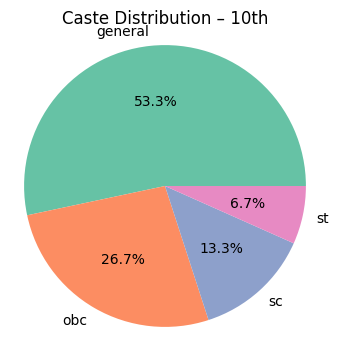

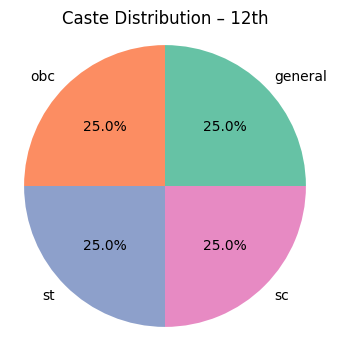

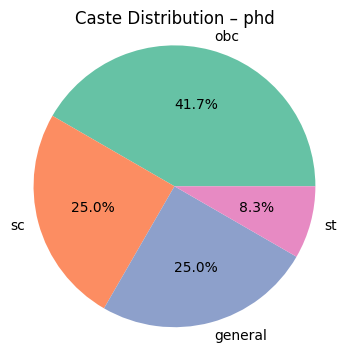

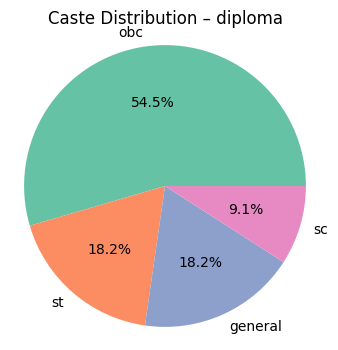

In [95]:
for qual in df['highest_qualification'].unique():
    group = df[df['highest_qualification'] == qual]['caste/category'].value_counts()
    
    plt.figure(figsize=(4, 4))
    plt.pie(group, labels=group.index, autopct='%1.1f%%', 
            colors=sns.color_palette('Set2'))
    plt.title(f'Caste Distribution – {qual}')
    plt.axis('equal')
    plt.show()


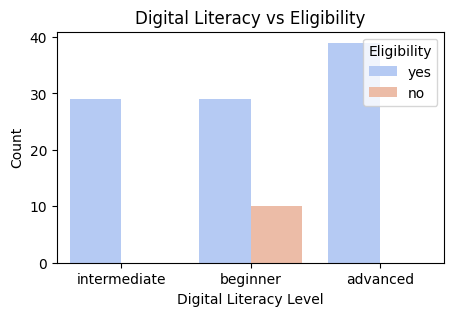

In [89]:
#Digital Literacy vs Eligibility
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='digital_literacy', hue='eligiblity', palette='coolwarm')
plt.title('Digital Literacy vs Eligibility')
plt.xlabel('Digital Literacy Level')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()

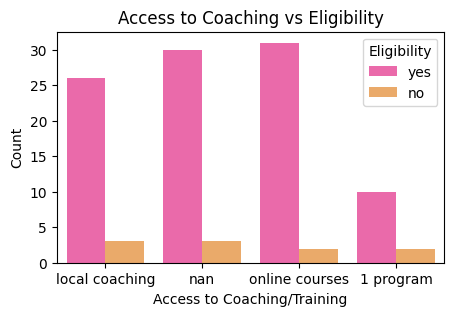

In [93]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='access_to_coaching/training', hue='eligiblity', palette='spring')
plt.title('Access to Coaching vs Eligibility')
plt.xlabel('Access to Coaching/Training')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()


In [ ]:
#Human Capital Attributes

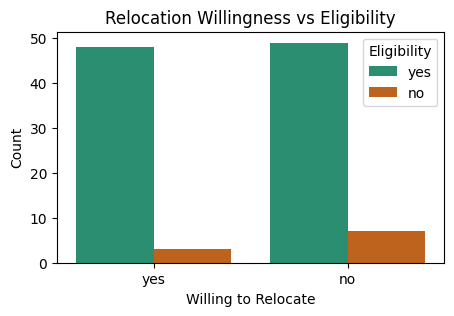

In [94]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='willing_to_relocate', hue='eligiblity', palette='Dark2')
plt.title('Relocation Willingness vs Eligibility')
plt.xlabel('Willing to Relocate')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()


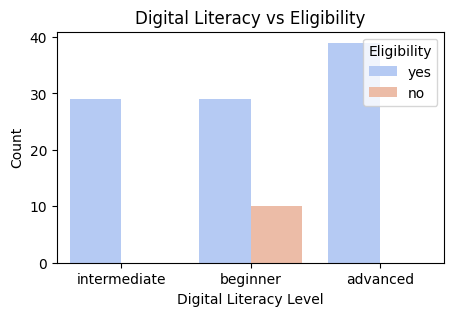

In [98]:
plt.figure(figsize=(5, 3))
sns.countplot(data=df, x='digital_literacy', hue='eligiblity', palette='coolwarm')
plt.title('Digital Literacy vs Eligibility')
plt.xlabel('Digital Literacy Level')
plt.ylabel('Count')
plt.legend(title='Eligibility')
plt.show()


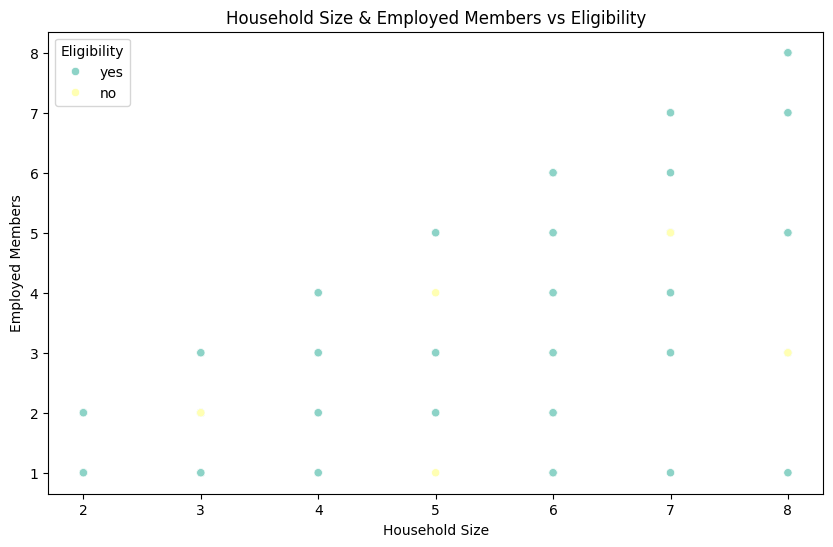

In [99]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='household_size', y='employed_members', hue='eligiblity', palette='Set3')
plt.title('Household Size & Employed Members vs Eligibility')
plt.xlabel('Household Size')
plt.ylabel('Employed Members')
plt.legend(title='Eligibility')
plt.show()


In [102]:
print(df.columns)

Index(['age', 'gender', 'literacy_status', 'highest_qualification',
       'field_of_study', 'experience_sector', 'job-related_skills',
       'household_size', 'employed_members', 'exams_attempted',
       'willing_to_relocate', 'digital_literacy', 'disability_status',
       'caste/category', 'marital_status', 'access_to_coaching/training',
       'eligiblity'],
      dtype='object')


   household_size  employed_members  Dependent Members
0               8                 5                  3
1               4                 4                  0
2               5                 2                  3
3               7                 7                  0
4               4                 3                  1
count    107.000000
mean       1.700935
std        1.666626
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max        7.000000
Name: Dependent Members, dtype: float64


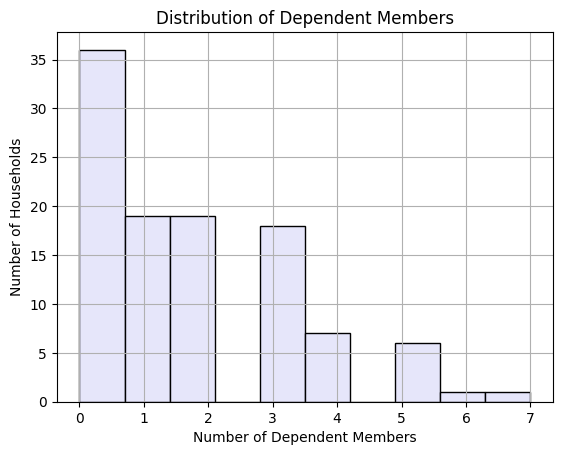

In [103]:
df['Dependent Members'] = df['household_size'] - df['employed_members']
print(df[['household_size', 'employed_members', 'Dependent Members']].head())

print(df['Dependent Members'].describe())
plt.hist(df['Dependent Members'], bins=10, color='lavender', edgecolor='black')
plt.title('Distribution of Dependent Members')
plt.xlabel('Number of Dependent Members')
plt.ylabel('Number of Households')
plt.grid(True)
plt.show()

digital_literacy   advanced   beginner  intermediate
Age Group                                           
<18               33.333333  44.444444     22.222222
18–25             35.294118  41.176471     23.529412
26–35             35.294118  32.352941     32.352941
36–45             42.857143  32.142857     25.000000
46–60              0.000000  50.000000     50.000000


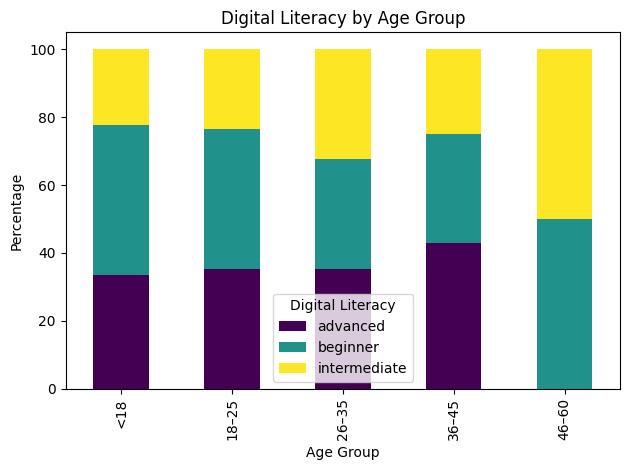

In [108]:
#  Bin Age for better grouping
df['Age Group'] = pd.cut(df['age'], bins=[0, 18, 25, 35, 45, 60, 100],
                         labels=['<18', '18–25', '26–35', '36–45', '46–60', '60+'])

age_ct = pd.crosstab(df['Age Group'], df['digital_literacy'], normalize='index') * 100
print(age_ct)
age_ct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title("Digital Literacy by Age Group")
plt.ylabel("Percentage")
plt.xlabel("Age Group")
plt.legend(title="Digital Literacy")
plt.tight_layout()
plt.show()